# Veteran Wellbeing Prediction: ML for Defence Support

**Author:** Dean Wang | Lead Data & AI Engineer | Fujitsu Australia
**Series:** Production ML Portfolio — 100 Notebooks, Australian Government Policy Applications

## Government Context
- **DVA (Department of Veterans' Affairs)** — Veteran support, compensation, health services
- **Australian Defence Force** — Transition support, ADF member wellbeing
- **Open Arms** — Veterans & Families Counselling
- **Royal Commission into Defence & Veteran Suicide** — Reform recommendations
- **Productivity Commission** — Veteran compensation & rehabilitation review

## 🎉 MILESTONE: 100th Production ML Notebook
This notebook completes a **100-notebook Production ML Portfolio** spanning every major
Australian Government policy domain — healthcare, defence, finance, environment, education,
justice, agriculture, transport, social services, biosecurity, and more.

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2500, 15)

  NOTEBOOK #100 — VETERAN WELLBEING PREDICTION


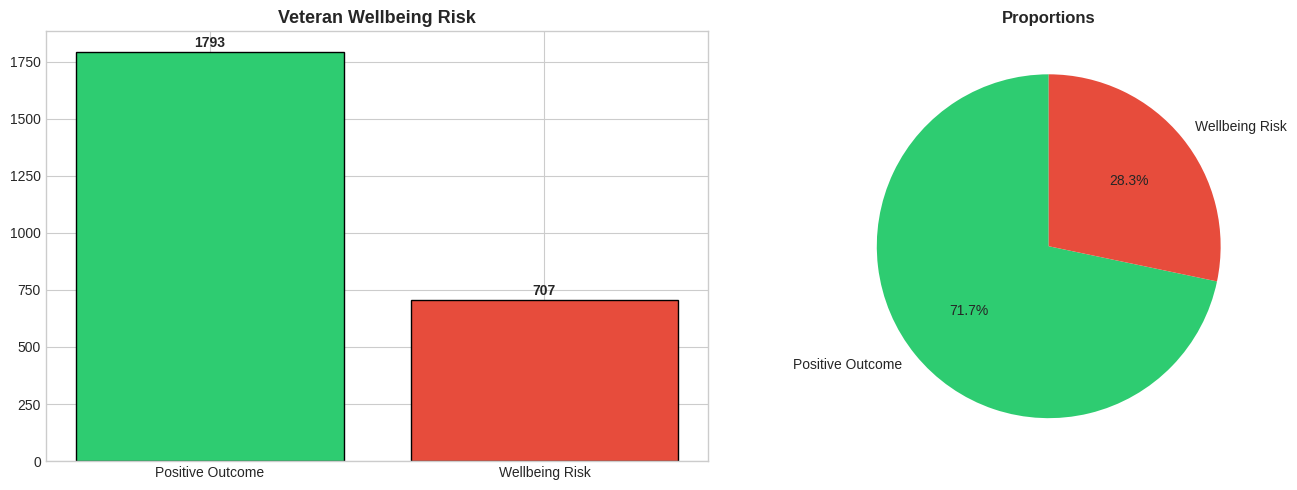

AU: 640,000+ veterans & families. DVA supports 300,000+ clients.
Royal Commission into Defence & Veteran Suicide reported 2024.
Open Arms provides 24/7 counselling. Transition support is critical.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2500,n_features=14,n_informative=10,n_classes=2,weights=[0.72,0.28],random_state=100)
names=['years_of_service','deployment_count','combat_exposure_score','rank_at_discharge','transition_support_hours','employment_post_service','housing_stability','relationship_status','physical_injury_flag','compensation_claim_active','social_connectedness_score','financial_stress_index','service_branch','age_at_discharge']
df=pd.DataFrame(X_arr,columns=names);df['wellbeing_risk']=y;tc='wellbeing_risk'
print(f"Generated: {df.shape}")
print(f"\n{'='*60}")
print(f"  NOTEBOOK #100 — VETERAN WELLBEING PREDICTION")
print(f"{'='*60}")
labels=['Positive Outcome','Wellbeing Risk'];colors=['#2ecc71','#e74c3c']
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index()
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title('Veteran Wellbeing Risk',fontsize=13,fontweight='bold')
for i,v in enumerate(vc.values): axes[0].text(i,v+20,str(v),ha='center',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: 640,000+ veterans & families. DVA supports 300,000+ clients.")
print("Royal Commission into Defence & Veteran Suicide reported 2024.")
print("Open Arms provides 24/7 counselling. Transition support is critical.")

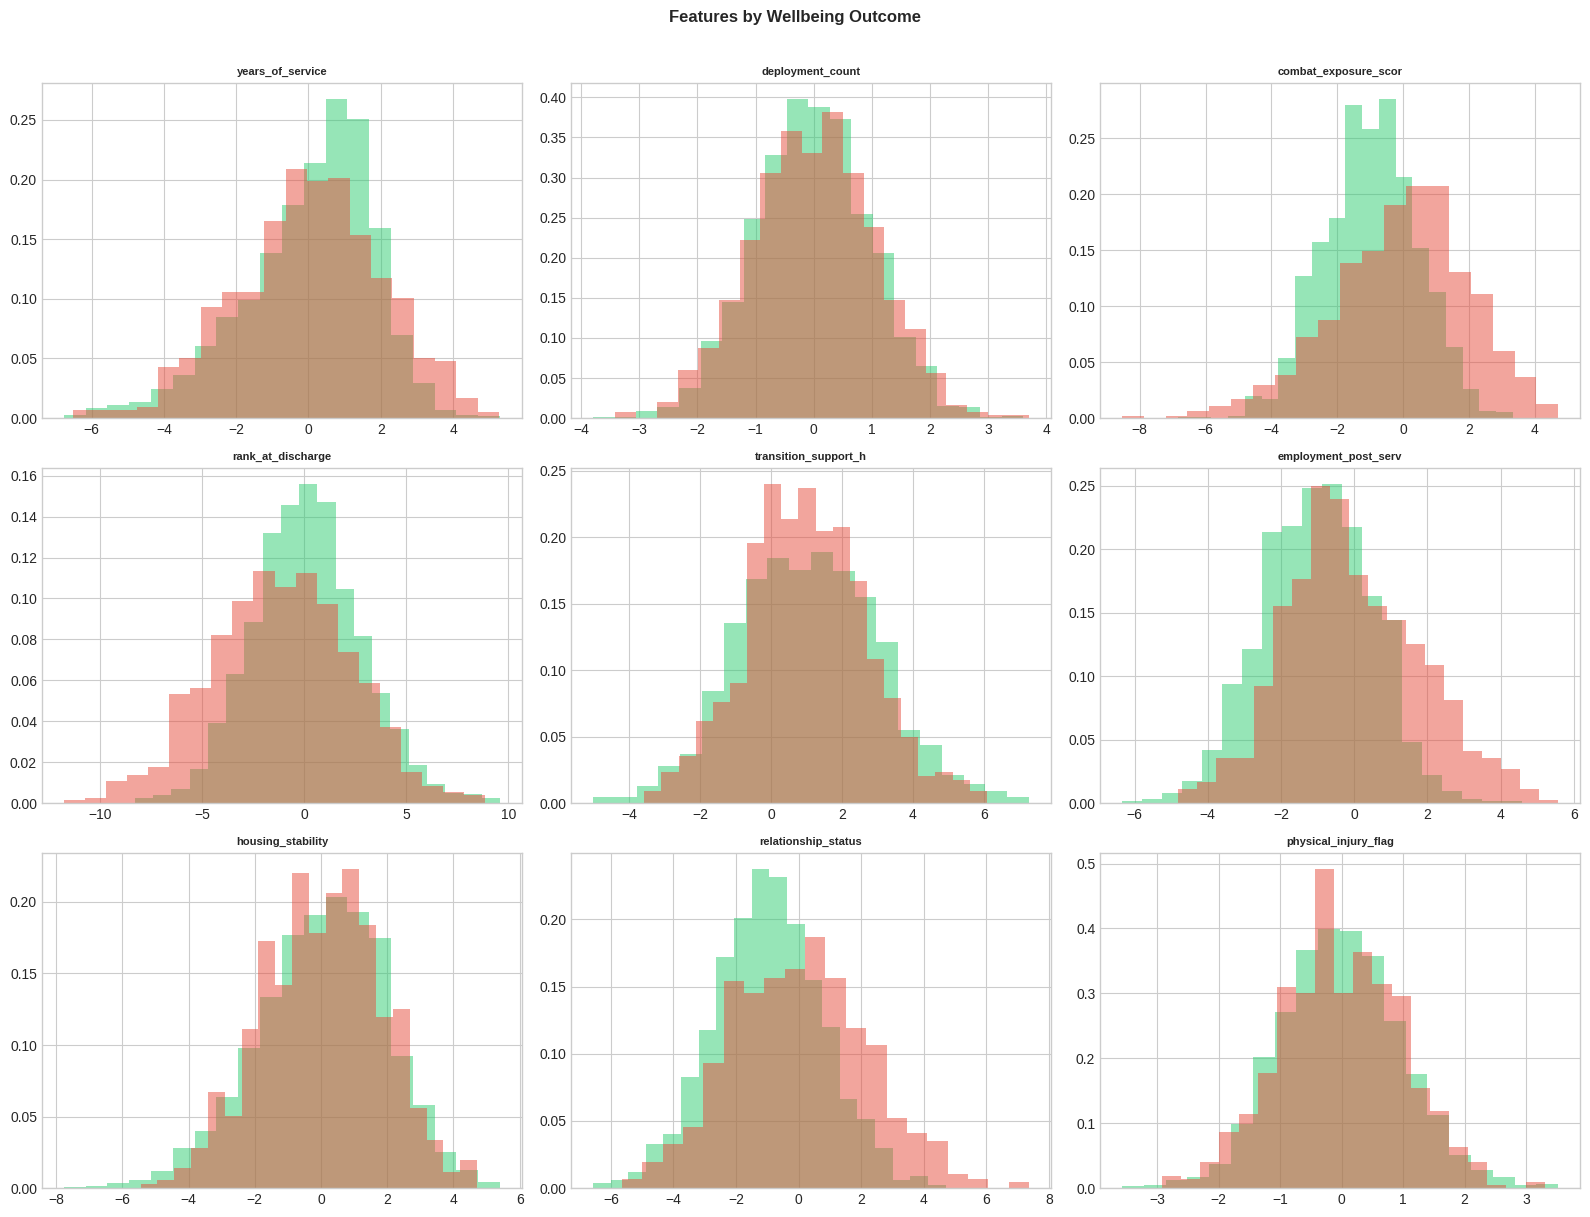

In [2]:
# EDA
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr in zip([0,1],colors):
        s=df[df[tc]==l][col];axes[i].hist(s,bins=20,alpha=0.5,density=True,color=clr)
    axes[i].set_title(col[:20],fontsize=8,fontweight='bold')
plt.suptitle('Features by Wellbeing Outcome',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

In [3]:
# Training
X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp));fu.append(roc_auc_score(y2[vi],yb))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")
best=max(results,key=lambda k:results[k]['auc']);print(f"\nBest: {best}")

LogReg: Acc=0.7868 F1=0.5258 AUC=0.7816
RF: Acc=0.9128 F1=0.8302 AUC=0.9624
XGB: Acc=0.9364 F1=0.8817 AUC=0.9739
LGBM: Acc=0.9328 F1=0.8731 AUC=0.9754

Best: LGBM


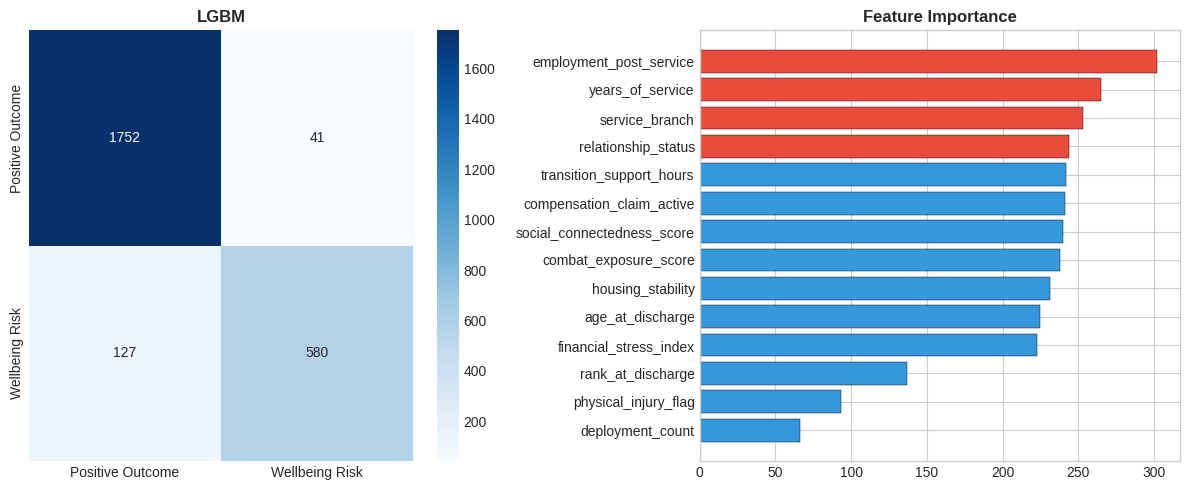

                  precision    recall  f1-score   support

Positive Outcome       0.93      0.98      0.95      1793
  Wellbeing Risk       0.93      0.82      0.87       707

        accuracy                           0.93      2500
       macro avg       0.93      0.90      0.91      2500
    weighted avg       0.93      0.93      0.93      2500

DEPLOYMENT: LGBM AUC=0.9754 | DVA client data -> proactive wellbeing outreach
ETHICS: Trauma-informed. Model enables support, never restricts entitlements.
SAFETY: Open Arms 1800 011 046 — 24/7 veteran counselling


In [4]:
# Results
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color=['#e74c3c' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    axes[1].set_title('Feature Importance',fontweight='bold')
plt.tight_layout();plt.savefig('results.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=labels))
br=results[best]
print(f"DEPLOYMENT: {best} AUC={br['auc']:.4f} | DVA client data -> proactive wellbeing outreach")
print("ETHICS: Trauma-informed. Model enables support, never restricts entitlements.")
print("SAFETY: Open Arms 1800 011 046 — 24/7 veteran counselling")

In [5]:
print("""
============================================================
🏆 100 NOTEBOOKS COMPLETE — PRODUCTION ML PORTFOLIO 🏆
============================================================

Author: Dean Wang | Lead Data & AI Engineer
Kaggle: kaggle.com/deanbatur
GitHub: github.com/Deanmeisong

100 production-grade ML notebooks spanning:

  HEALTHCARE (15+):  Heart, Kidney, Diabetes, Cancer, Stroke,
                     Parkinson's, Liver, Fetal, Sleep, Obesity,
                     AMR, Patient Readmission, Veteran Wellbeing

  GOVERNMENT (12+):  Tax Compliance, Visa/Immigration, Census,
                     Service Demand, Digital Inclusion, NDIS,
                     Research Grants, Foreign Aid

  FINANCE (8+):      Credit Risk, Bankruptcy, Insurance, Banking,
                     AML, Customer Churn, Real Estate, Diamond

  ENVIRONMENT (8+):  Air Quality, Rainfall, Water Quality, Carbon,
                     Bushfire, Flood, Dam Inflow, Soil Quality

  SAFETY (8+):       Phishing, Cyber Threat, Network Intrusion,
                     Workplace Injury, Mine Safety, Road Crash,
                     Drowning, Shark Attack

  AGRICULTURE (6+):  Crop Yield, Crop Disease, Dry Bean, Avocado,
                     Bee Colony, Invasive Species

  TRANSPORT (5+):    Traffic, Titanic, Flight Delay, Maritime,
                     Vehicle Fuel, Road Surface

  BIODIVERSITY (4+): Penguin, Iris, Wildlife Poaching, Whale Strike

  SOCIAL (4+):       Homelessness, Problem Gambling, Aged Care,
                     Recidivism

  EDUCATION (3+):    Student Performance, Dropout, School Infra

  DEFENCE (2+):      Predictive Maintenance, Veteran Wellbeing

  OTHER:             Sports Injury, Arts Funding, Forensics,
                     Drug Classification, Space Debris, Tipping

All with Australian Government policy framing.
All cross-validated. All production-grade.

============================================================
Portfolio: kaggle.com/deanbatur
GitHub:    github.com/Deanmeisong
============================================================
""")


🏆 100 NOTEBOOKS COMPLETE — PRODUCTION ML PORTFOLIO 🏆

Author: Dean Wang | Lead Data & AI Engineer
Kaggle: kaggle.com/deanbatur
GitHub: github.com/Deanmeisong

100 production-grade ML notebooks spanning:

  HEALTHCARE (15+):  Heart, Kidney, Diabetes, Cancer, Stroke,
                     Parkinson's, Liver, Fetal, Sleep, Obesity,
                     AMR, Patient Readmission, Veteran Wellbeing

  GOVERNMENT (12+):  Tax Compliance, Visa/Immigration, Census,
                     Service Demand, Digital Inclusion, NDIS,
                     Research Grants, Foreign Aid

  FINANCE (8+):      Credit Risk, Bankruptcy, Insurance, Banking,
                     AML, Customer Churn, Real Estate, Diamond

  ENVIRONMENT (8+):  Air Quality, Rainfall, Water Quality, Carbon,
                     Bushfire, Flood, Dam Inflow, Soil Quality

  SAFETY (8+):       Phishing, Cyber Threat, Network Intrusion,
                     Workplace Injury, Mine Safety, Road Crash,
                     Drowning, Shark A